# **AML LAB**

## **Lab 6 (Experiment 5) - 02/03/2026**

##Spam Email Detection: Build a spam email filter using text classification algorithms and perform comparative analysis. (Naïve Bayes, Logistic Regression, Support Vector Machine, Decision Tree, Random Forest)

###1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve

###2. Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Applied_ML_Lab/Lab_6/spam_email.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


###3. Data Understanding

In [ ]:
df.info()
df.isnull().sum()

# Check class distribution
df['Category'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
Category,
ham,4825
spam,747


###4. Text Feature Extraction (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Message'])
y = df['Category']

###5. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###6. Initialize Models

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

###7. Train, Predict, Evaluate

In [ ]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', pos_label='spam')
    recall = recall_score(y_test, y_pred, average='binary', pos_label='spam')
    f1 = f1_score(y_test, y_pred, average='binary', pos_label='spam')

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For SVC, decision_function returns the distance of samples to the hyperplane.
        # If the target is binary, it's typically for the positive class.
        # Need to ensure the order of classes in model.classes_ for consistency.
        if 'spam' in model.classes_:
            spam_class_idx = list(model.classes_).index('spam')
            # If 'spam' is the 0th class, and decision_function aligns with 1st, might need adjustment.
            # For binary, usually decision_function output directly relates to positive class.
            # Let's assume positive corresponds to decision_function > 0.
            y_prob = model.decision_function(X_test)
            # If SVC's decision_function doesn't directly map to probabilities,
            # it's best to use predict_proba or handle carefully.
            # Given the error is about pos_label, the probability output for roc_auc_score needs to be consistent.
        else:
            y_prob = model.decision_function(X_test)

    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = [accuracy, precision, recall, f1, roc_auc]

    print("\nModel:", name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("ROC-AUC:", roc_auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model: Naive Bayes
Accuracy: 0.9775784753363229
Precision: 1.0
Recall: 0.8322147651006712
F1-Score: 0.9084249084249084
ROC-AUC: 0.9853821890588742
Confusion Matrix:
 [[966   0]
 [ 25 124]]

Model: Logistic Regression
Accuracy: 0.95695067264574
Precision: 1.0
Recall: 0.6778523489932886
F1-Score: 0.808
ROC-AUC: 0.9883905123181458
Confusion Matrix:
 [[966   0]
 [ 48 101]]

Model: Support Vector Machine
Accuracy: 0.9775784753363229
Precision: 1.0
Recall: 0.8322147651006712
F1-Score: 0.9084249084249084
ROC-AUC: 0.9911765114566399
Confusion Matrix:
 [[966   0]
 [ 25 124]]

Model: Decision Tree
Accuracy: 0.967713004484305
Precision: 0.9124087591240876
Recall: 0.8389261744966443
F1-Score: 0.8741258741258742
ROC-AUC: 0.9132519071240985
Confusion Matrix:
 [[954  12]
 [ 24 125]]

Model: Random Forest
Accuracy: 0.9802690582959641
Precision: 1.0
Recall: 0.8523489932885906
F1-Score: 0.9202898550724637
ROC-AUC: 0.9921005460836215
Confusion Matrix:
 [[966   0]
 [ 22 127]]


###8. Create Comparison Table

In [ ]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

results_df

,Naive Bayes,Logistic Regression,Support Vector Machine,Decision Tree,Random Forest
Accuracy,0.977578,0.956951,0.977578,0.967713,0.980269
Precision,1.000000,1.000000,1.000000,0.912409,1.000000
Recall,0.832215,0.677852,0.832215,0.838926,0.852349
F1-Score,0.908425,0.808000,0.908425,0.874126,0.920290
ROC-AUC,0.985382,0.988391,0.991177,0.913252,0.992101


###9. Visualization: Model Comparison Bar Chart

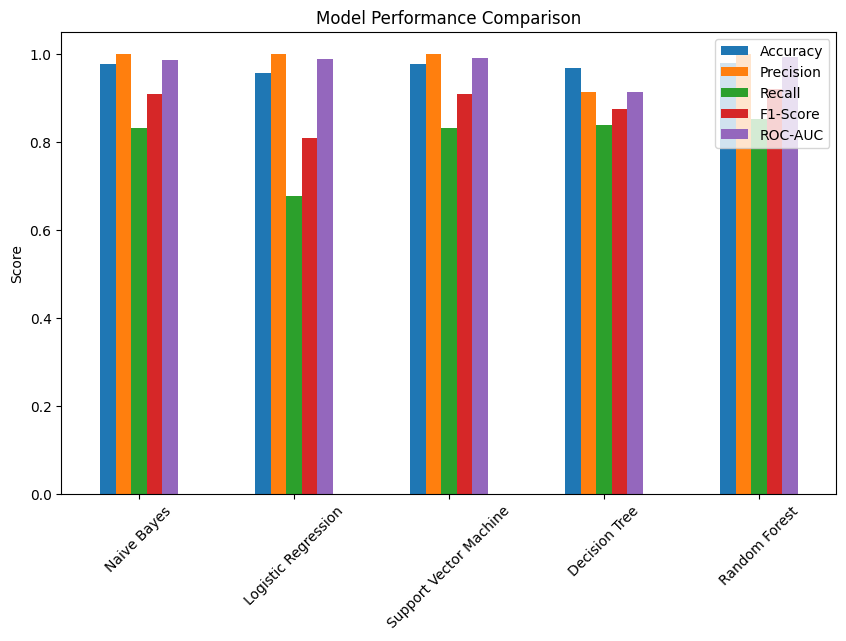

In [ ]:
results_df.T.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

###10. ROC Curve Visualization

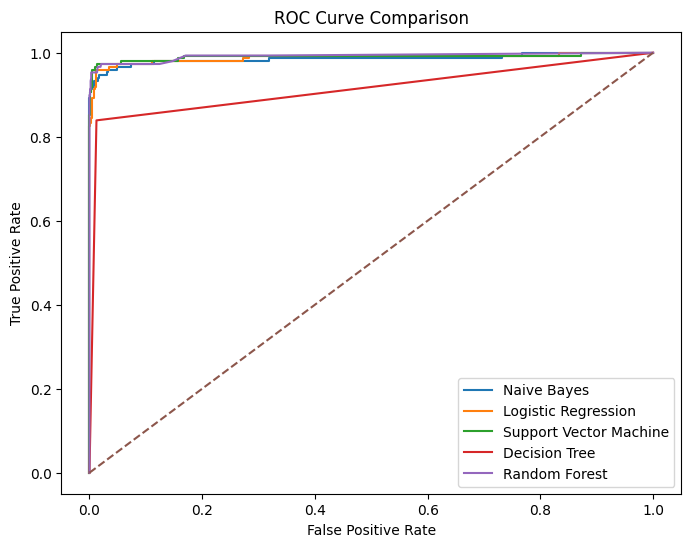

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label='spam')
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()